In [ ]:
import pandas as pd
import numpy as np

# Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Explainability
import shap
import matplotlib.pyplot as plt

In [91]:
df = pd.read_csv("telco_cleaned_data.csv")

drop_cols = [
    "Customer ID",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Latitude",
    "Longitude",
    "Population",
    "Customer Status",
    "Churn Score",
    "Churn Category",
    "Churn Reason",
    "CLTV",
    "Total Revenue",
    "Unnamed: 0",
    "Total Charges",
    "Total Extra Data Charges",
    "Total Long Distance Charges",
    "Total Revenue",
    "Total Refunds",
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])
df.to_csv("telco_cleaned_dataset.csv")

df.head()

,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Quarter,Referred a Friend,Number of Referrals,...,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Satisfaction Score,Churn Label
0,Male,78,No,Yes,No,No,0,Q3,No,0,...,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,3,Yes
1,Female,74,No,Yes,Yes,Yes,1,Q3,Yes,1,...,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,3,Yes
2,Male,71,No,Yes,No,Yes,3,Q3,No,0,...,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,2,Yes
3,Female,78,No,Yes,Yes,Yes,1,Q3,Yes,1,...,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2,Yes
4,Female,80,No,Yes,Yes,Yes,1,Q3,Yes,1,...,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2,Yes


In [ ]:
df['Churn Label'] = df['Churn Label'].map({'Yes':1, 'No':0})

In [ ]:
df.shape

(7043, 32)

In [ ]:
df.head()

,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Quarter,Referred a Friend,Number of Referrals,...,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Satisfaction Score,Churn Label
0,Male,78,No,Yes,No,No,0,Q3,No,0,...,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,3,1
1,Female,74,No,Yes,Yes,Yes,1,Q3,Yes,1,...,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,3,1
2,Male,71,No,Yes,No,Yes,3,Q3,No,0,...,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,2,1
3,Female,78,No,Yes,Yes,Yes,1,Q3,Yes,1,...,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2,1
4,Female,80,No,Yes,Yes,Yes,1,Q3,Yes,1,...,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2,1


In [ ]:
X = df.drop("Churn Label", axis=1)
y = df["Churn Label"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Train Using Random Forest Model

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

Train Using XGBoost Model

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:54:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

Model Testing & Evaluation Using Random Forest

In [ ]:
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9524485450674237
ROC AUC: 0.9829729520266605
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1035
           1       0.99      0.83      0.90       374

    accuracy                           0.95      1409
   macro avg       0.96      0.91      0.94      1409
weighted avg       0.95      0.95      0.95      1409



Model Testing & Evaluation Using XGBoost

In [ ]:
xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9588360539389638
ROC AUC: 0.9910950941641479
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1035
           1       0.94      0.90      0.92       374

    accuracy                           0.96      1409
   macro avg       0.95      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



Combine Both Models

In [ ]:
from sklearn.ensemble import VotingClassifier

ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    voting='soft'
)

ensemble_model.fit(X_train, y_train)

ensemble_pred = ensemble_model.predict(X_test)

print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_pred))
print("Ensemble ROC AUC:", roc_auc_score(y_test, ensemble_model.predict_proba(X_test)[:,1]))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:54:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Ensemble Accuracy: 0.9588360539389638
Ensemble ROC AUC: 0.98682993619055


SHAP Explainability

In [ ]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

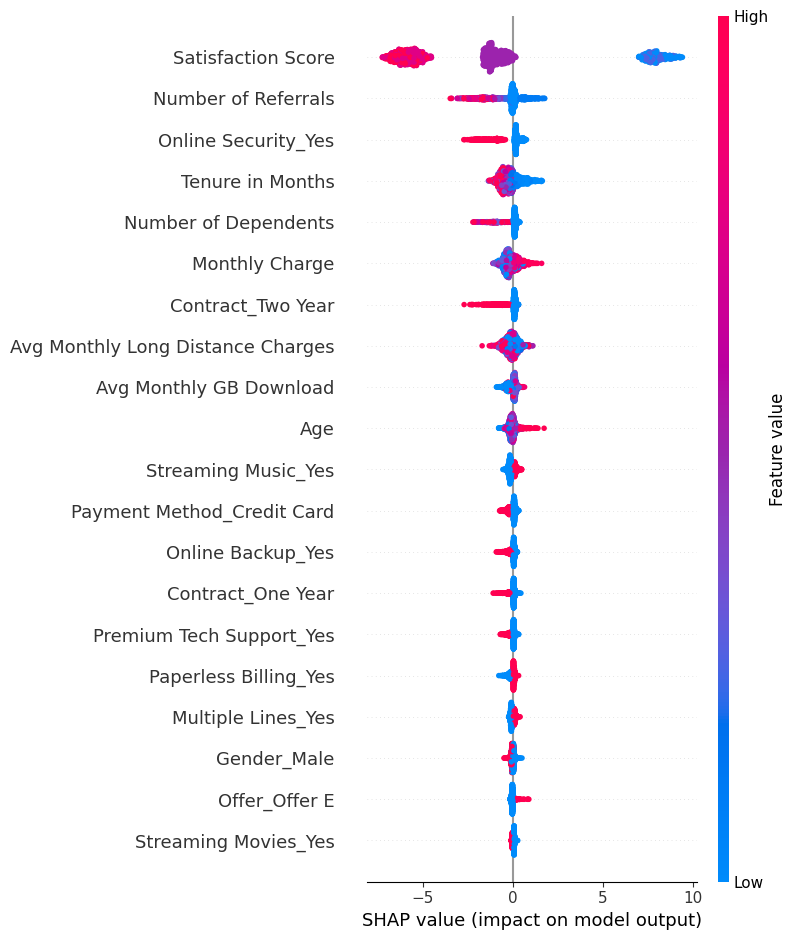

In [ ]:
shap.summary_plot(shap_values, X_test)